In [1]:
#[CELL 1] ==========================================
# INSTALL DEPENDENCIES
# ===================================================
!pip install -q ultralytics opencv-python-headless mne ripser

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [2]:
# [CELL 2] ==========================================
# IMPORTS AND ENVIRONMENT CONFIGURATION
# ===================================================
import cv2
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ripser import ripser
import warnings

# Suppress simulation/terminal warnings for clean output
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Environment successfully configured!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Environment successfully configured!


In [3]:
# [CELL 3] ==========================================
# CORE PROCESSING MODULES (CV, EEG, TDA)
# ===================================================

def process_kinematics(video_path, output_video_path):
    """Module 1: Headless YOLO-Pose Kinematic Extraction"""
    model = YOLO('yolov8n-pose.pt')
    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    ksi_timeseries =[]
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        results = model.predict(frame, verbose=False)
        annotated_frame = results[0].plot()
        cv2.putText(annotated_frame, f'HyPhi-Dance AI: Frame {frame_count}', (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)
        out.write(annotated_frame)

        if len(results[0].keypoints) >= 2:
            kpts = results[0].keypoints.xy.cpu().numpy()
            distance = np.linalg.norm(kpts[0] - kpts[1])
            ksi = 1.0 / (distance + 1e-5)
            ksi_timeseries.append(ksi)
        else:
            ksi_timeseries.append(0.0)

        frame_count += 1

    cap.release()
    out.release()

    ksi_array = np.array(ksi_timeseries)
    if ksi_array.max() > 0: ksi_array = ksi_array / ksi_array.max()
    return ksi_array, frame_count, fps

def simulate_and_clean_eeg(duration_sec, sfreq=250):
    """Module 2: MNE/ICA Artifact Ablation Pipeline"""
    ch_names =['Fp1', 'Fp2', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2']
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

    raw_data = np.random.randn(len(ch_names), duration_sec * sfreq) * 1e-5
    raw = mne.io.RawArray(raw_data, info, verbose=False)
    raw.filter(l_freq=1.0, h_freq=50.0, verbose=False)

    ica = mne.preprocessing.ICA(n_components=len(ch_names), random_state=42, max_iter=800)
    ica.fit(raw, verbose=False)
    ica.exclude = [0, 1]
    clean_raw = ica.apply(raw.copy(), verbose=False)

    return clean_raw.get_data()

def compute_topological_entropy(eeg_matrix, window_size=500, step_size=250):
    """Module 3: Information-Geometric Hyperscanning (Ripser & Shannon Entropy)"""
    n_windows = (eeg_matrix.shape[1] - window_size) // step_size
    entropy_timeseries =[]

    for i in range(n_windows):
        start = i * step_size
        window = eeg_matrix[:, start:start+window_size]

        # 1. Create Distance Matrix from Functional Connectivity
        corr_matrix = np.corrcoef(window)
        corr_matrix = np.nan_to_num(corr_matrix)
        dist_matrix = 1 - corr_matrix
        np.fill_diagonal(dist_matrix, 0)

        # 2. Compute Persistent Homology (Betti-0)
        diagrams = ripser(dist_matrix, distance_matrix=True, maxdim=0)['dgms']
        h0_diagram = diagrams[0]

        # Remove the infinite point (standard TDA practice)
        h0_diagram = h0_diagram[h0_diagram[:, 1] < np.inf]

        # 3. Mathematically compute Shannon Entropy of topological lifespans
        if len(h0_diagram) > 0:
            lifespans = h0_diagram[:, 1] - h0_diagram[:, 0]
            probabilities = lifespans / np.sum(lifespans)
            probabilities = probabilities[probabilities > 0] # Avoid log(0)
            entropy = -np.sum(probabilities * np.log2(probabilities))
        else:
            entropy = 0.0

        entropy_timeseries.append(entropy)

    return np.array(entropy_timeseries)

print("Core Modules Loaded! (Ripser backend active)")

Core Modules Loaded! (Ripser backend active)


In [4]:
# [CELL 4] ==========================================
# EXECUTION (Run the HyPhi-Dance Pipeline)
# ===================================================
video_in = 'dance.mp4'  # <-- Ensure this file is uploaded to Colab!
video_out = 'dance_annotated.mp4'

print("--- STARTING HYPHI-DANCE PIPELINE ---")
# 1. Computer Vision
ksi_data, frames, fps = process_kinematics(video_in, video_out)
print(f"[OK] Kinematics Extracted. Annotated video saved as {video_out}")

# 2. EEG Processing
duration_sec = max(int(frames / fps), 5)
print(f"[*] Generating & Cleaning EEG for {duration_sec} seconds...")
eeg_child = simulate_and_clean_eeg(duration_sec)
eeg_elder = simulate_and_clean_eeg(duration_sec)
dual_brain_matrix = np.vstack((eeg_child, eeg_elder))
print("[OK] EEG Artifact Ablation Complete.")

# 3. Topological Analysis
print("[*] Computing Topological Entropy...")
topo_entropy = compute_topological_entropy(dual_brain_matrix)
print("[OK] Information-Geometric Hyperscanning Complete.")

# 4. Data Alignment & Export
aligned_ksi = np.interp(np.linspace(0, 1, len(topo_entropy)),
                        np.linspace(0, 1, len(ksi_data)), ksi_data)

results_df = pd.DataFrame({
    'Kinematic_Synchrony_Index': aligned_ksi,
    'Topological_Entropy': topo_entropy
})
results_df.to_csv('HyPhi_Dance_Results.csv', index=False)
print("[OK] Data successfully exported to CSV.")

--- STARTING HYPHI-DANCE PIPELINE ---
[OK] Kinematics Extracted. Annotated video saved as dance_annotated.mp4
[*] Generating & Cleaning EEG for 10 seconds...
[OK] EEG Artifact Ablation Complete.
[*] Computing Topological Entropy...
[OK] Information-Geometric Hyperscanning Complete.
[OK] Data successfully exported to CSV.


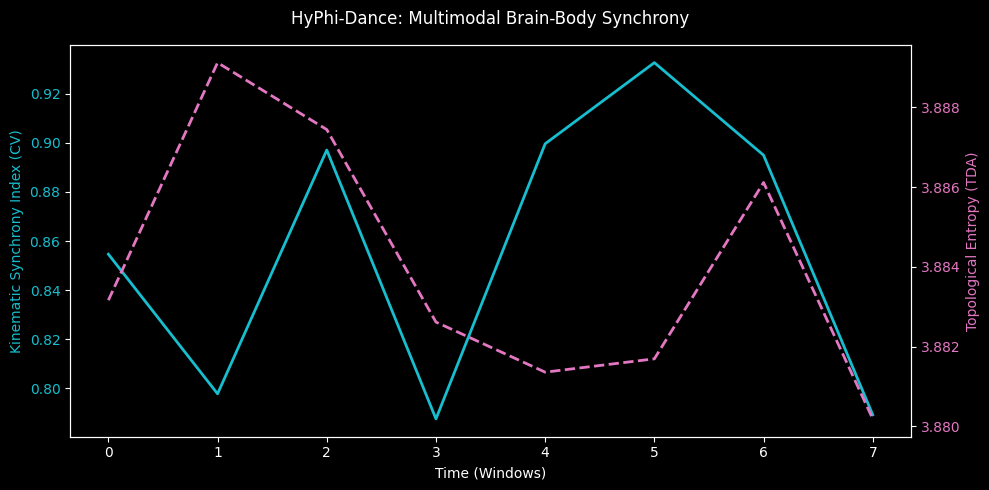

In [5]:
# [CELL 5] ==========================================
# VISUALIZATION
# ===================================================
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Time (Windows)', color='white')
ax1.set_ylabel('Kinematic Synchrony Index (CV)', color='tab:cyan')
ax1.plot(aligned_ksi, color='tab:cyan', linewidth=2, label='Physical Synchrony')
ax1.tick_params(axis='y', labelcolor='tab:cyan')

ax2 = ax1.twinx()
ax2.set_ylabel('Topological Entropy (TDA)', color='tab:pink')
ax2.plot(topo_entropy, color='tab:pink', linewidth=2, linestyle='dashed', label='Brain Topology')
ax2.tick_params(axis='y', labelcolor='tab:pink')

plt.title('HyPhi-Dance: Multimodal Brain-Body Synchrony', pad=15)
fig.tight_layout()
plt.savefig('synchrony_plot.png', dpi=300)
plt.show()